# Baseline Models: Logistic Regression, Random Forest, XGBoost, LightGBM

## Load Data & Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)

# Load train-test splits
splits_dir = Path('../data/processed/splits')

with open(splits_dir / 'X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(splits_dir / 'X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(splits_dir / 'y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open(splits_dir / 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

with open('../models/imbalance_config.pkl', 'rb') as f:
    imbalance_config = pickle.load(f)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Imbalance config: {imbalance_config}")

X_train: (4930, 30), X_test: (2113, 30)
Imbalance config: {'scale_pos_weight': np.float64(2.7691131498470947), 'strategy': 'class_weight'}


## Modeling Approach

We train 4 baseline models to compare performance before building the final ensemble:
1. Logistic Regression for simple linear baseline
2. Random Forest: tree-based baseline, robust and interpretable
3. XGBoost: gradient boosting, typically strongest performer on tabular data
4. LightGBM that similar to XGBoost, faster training

Primary metric: **ROC-AUC** (more informative than accuracy on imbalanced data).
Class imbalance handled via class weights for all models.

## Helper Function for Evaluation

In [2]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a trained model and return metrics dict"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'model': model_name,
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

    print(f"{model_name}")
    print('=' * 60)
    for key, val in metrics.items():
        if key != 'model':
            print(f"{key.upper()}: {val:.3f}")

    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return metrics, y_pred_proba

# Store results for comparison
results = []
proba_predictions = {}

## Model 1: Logistic Regression

In [3]:
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train, y_train)

metrics_lr, proba_lr = evaluate_model(log_reg, X_test, y_test, 'Logistic Regression')
results.append(metrics_lr)
proba_predictions['Logistic Regression'] = proba_lr

Logistic Regression
ROC_AUC: 0.844
ACCURACY: 0.744
PRECISION: 0.511
RECALL: 0.797
F1: 0.623

Confusion Matrix:
[[1125  427]
 [ 114  447]]


## Model 2: Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

metrics_rf, proba_rf = evaluate_model(rf, X_test, y_test, 'Random Forest')
results.append(metrics_rf)
proba_predictions['Random Forest'] = proba_rf

Random Forest
ROC_AUC: 0.839
ACCURACY: 0.764
PRECISION: 0.539
RECALL: 0.775
F1: 0.636

Confusion Matrix:
[[1180  372]
 [ 126  435]]


## Model 3: XGBoost

In [5]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_config['scale_pos_weight'],
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)

metrics_xgb, proba_xgb = evaluate_model(xgb, X_test, y_test, 'XGBoost')
results.append(metrics_xgb)
proba_predictions['XGBoost'] = proba_xgb

XGBoost
ROC_AUC: 0.836
ACCURACY: 0.751
PRECISION: 0.521
RECALL: 0.772
F1: 0.622

Confusion Matrix:
[[1154  398]
 [ 128  433]]


## Model 4: LightGBM

In [6]:
lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb.fit(X_train, y_train)

metrics_lgb, proba_lgb = evaluate_model(lgb, X_test, y_test, 'LightGBM')
results.append(metrics_lgb)
proba_predictions['LightGBM'] = proba_lgb

LightGBM
ROC_AUC: 0.834
ACCURACY: 0.755
PRECISION: 0.526
RECALL: 0.774
F1: 0.626

Confusion Matrix:
[[1161  391]
 [ 127  434]]


## Compare All Models by Table

In [7]:
print("MODEL COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(results_df.round(3))

MODEL COMPARISON
                 model  roc_auc  accuracy  precision  recall     f1
0  Logistic Regression    0.844     0.744      0.511   0.797  0.623
1        Random Forest    0.839     0.764      0.539   0.775  0.636
2              XGBoost    0.836     0.751      0.521   0.772  0.622
3             LightGBM    0.834     0.755      0.526   0.774  0.626


## Compare All Models by ROC Curve

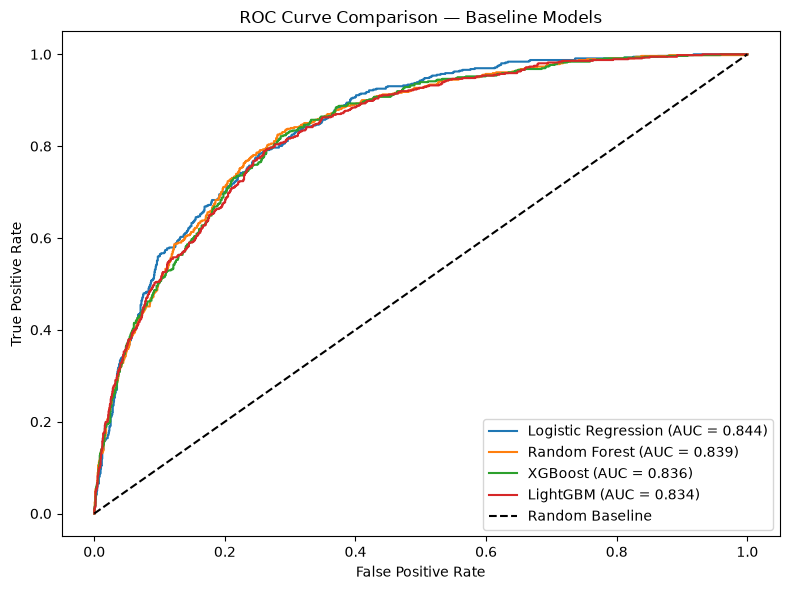

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, proba in proba_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Baseline Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Compare by Bar Chart of Key Metrics

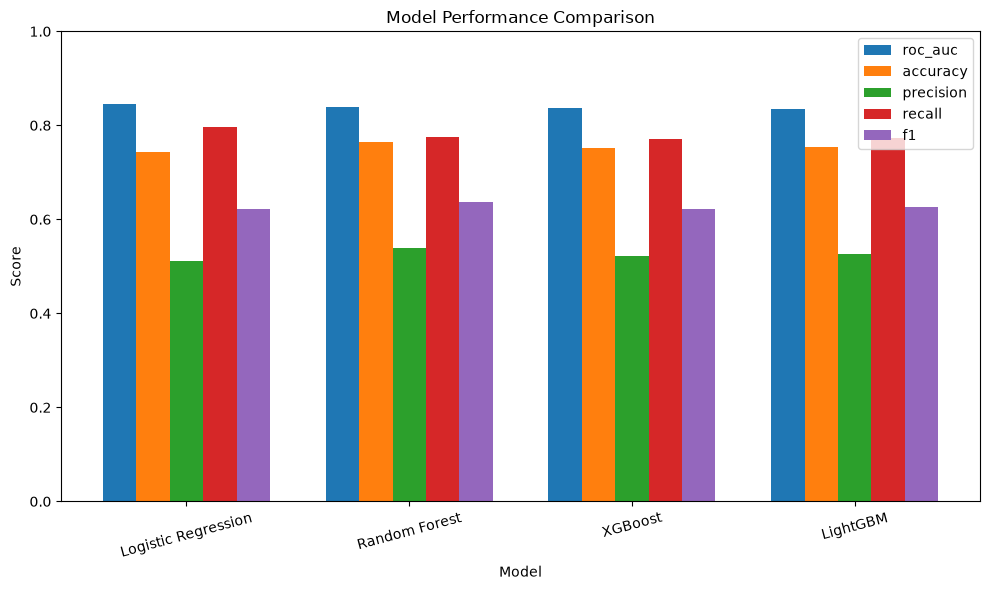

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['model'], rotation=15)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Save Baseline Models

In [10]:
print("SAVING BASELINE MODELS")
print("=" * 60)

baseline_models_dir = Path('../models/baseline')
baseline_models_dir.mkdir(exist_ok=True)

models_to_save = {
    'logistic_regression': log_reg,
    'random_forest': rf,
    'xgboost': xgb,
    'lightgbm': lgb
}

for name, model in models_to_save.items():
    with open(baseline_models_dir / f'{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

# Save results table too
results_df.to_csv(baseline_models_dir / 'baseline_results.csv', index=False)

print("Saved all baseline models and results table")

SAVING BASELINE MODELS
Saved all baseline models and results table


## Baseline Model Results Summary

| Model | ROC-AUC | Accuracy | Precision | Recall | F1 |
|-------|---------|----------|-----------|--------|-----|
| Logistic Regression | 0.844 | 0.744 | 0.511 | 0.797 | 0.623 |
| Random Forest | 0.839 | 0.764 | 0.539 | 0.775 | 0.636 |
| XGBoost | 0.836 | 0.751 | 0.521 | 0.772 | 0.622 |
| LightGBM | 0.834 | 0.755 | 0.526 | 0.774 | 0.626 |

**Observations:**
- All four models perform very closely (ROC-AUC within a 0.01 range), suggesting the decision boundary for churn in this dataset is close to linear after encoding. Boosting models gain little advantage over Logistic Regression here.
- Logistic Regression achieves the highest ROC-AUC (0.844), while Random Forest has the best F1-score (0.636), showing the best precision-recall balance.
- Accuracy is modest (74-76%) relative to ROC-AUC because `class_weight='balanced'` intentionally trades precision for recall — the models catch ~77-80% of actual churners at the cost of more false positives. This trade-off is reasonable for churn prediction, where missing a customer who churns is typically costlier than a false alarm.